In [66]:
# Imports and Setup and Parameters
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset
import sys
import os
import random
from tqdm.auto import tqdm
from scipy.stats import shapiro, levene, probplot
from statsmodels.stats.oneway import anova_oneway
import itertools
import numpy as np
import ast
import scipy.stats as stats
from statsmodels.multivariate.manova import MANOVA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler



# Add 'lang_complexity' to python path
sys.path.append(os.path.abspath('lang_complexity'))

from lang_complexity.complexity import complexities

# Jupyter magic command to display plots inline
%matplotlib inline

# List of Compleity Metric for Variance Analysis
SELECTED_METRICS = [
    "morphology_deletion_bzip2", 
    "morphology_deletion_gzip", 
    "morphology_replacement_bzip2", 
    "morphology_replacement_gzip", 
    "syntactic_deletion_bzip2", 
    "syntactic_deletion_gzip"]


METRIC_LABELS = {"morphology_deletion_bzip2": "$C_m$ (bzip2)",
                 "morphology_deletion_gzip": "$C_m$ (gzip)",
                 "syntactic_deletion_bzip2": "$C_s$ (bzip2)",
                 "syntactic_deletion_gzip": "$C_s$ (gzip)",
                 "morphology_replacement_bzip2": "$C_m^*$ (bzip2)",
                 "morphology_replacement_gzip": "$C_m^*$ (gzip)"}




In [26]:
# Loading Experiments Data
variance_experiments_df = pd.read_csv('variance_experiments.csv',
                                      converters={'source_indices': ast.literal_eval})

variance_experiments_df.head()

,register,source_indices,morphology_deletion_bzip2,morphology_deletion_gzip,morphology_replacement_bzip2,morphology_replacement_gzip,syntactic_deletion_bzip2,syntactic_deletion_gzip
0,Article,"[3224733, 2661407, 2354022, 4483192, 3511467, ...",-1.058312,-1.013345,1.674972,1.437400,0.947044,0.928346
1,Article,"[3490768, 2617225, 2562585, 42158, 3301123, 25...",-1.056959,-1.014640,1.667235,1.438136,0.941075,0.933949
2,Article,"[3226419, 2535317, 3787202, 216565, 1025114, 3...",-1.057896,-1.012698,1.646208,1.416951,0.944832,0.932367
3,Article,"[2532628, 3470241, 353591, 2737641, 2723018, 1...",-1.048943,-1.008848,1.684470,1.450694,0.935203,0.929794
4,Article,"[4030436, 424703, 2503989, 2782972, 338283, 20...",-1.049623,-1.005455,1.716326,1.461841,0.923855,0.931220


# Examining Correlation between metrics: Trade-off and Redundancy

In [27]:
def analyze_correlation_matrix(df, metrics_list, metric_labels=None, plot=True):
    """
    Calculates the Pearson correlation matrix between the provided metrics and 
    plots a triangular heatmap using Seaborn with optional LaTeX labels.
    
    Args:
        df (pd.DataFrame): Dataframe containing the data.
        metrics_list (list): List of numerical columns.
        metric_labels (dict, optional): Dictionary mapping column names to LaTeX labels 
        plot (bool): If True, displays the triangular heatmap.
        
    Returns:
        pd.DataFrame: Correlation matrix with original names (values between -1 and 1).
    """
    # Validation and Filter
    valid_metrics = [m for m in metrics_list if m in df.columns]
    
    if len(valid_metrics) < 2:
        print("Warning: At least two metrics are required for correlation.")
        return pd.DataFrame()

    print(f"--- Calculating Correlation Matrix for {len(valid_metrics)} metrics ---")

    # Correlation Calculation
    corr_matrix = df[valid_metrics].corr(method='pearson')

    # Visual Highlight 
    high_corr_pairs = []
    
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            val = corr_matrix.iloc[i, j]
            if abs(val) > 0.8:
                high_corr_pairs.append((col1, col2, val))
    
    if high_corr_pairs:
        print(f"ALERT: {len(high_corr_pairs)} pairs of metrics show high redundancy (>0.8):")
        for c1, c2, val in high_corr_pairs:
            print(f"   - {c1} vs {c2}: {val:.2f}")
    else:
        print("No critical redundancy (>0.8) detected.")

    # Plotting the Triangular Heatmap
    if plot:
        plt.figure(figsize=(10, 8))
        
        # Create a temporary matrix for plotting with renamed labels if provided
        if metric_labels:
            plot_matrix = corr_matrix.rename(index=metric_labels, columns=metric_labels)
        else:
            plot_matrix = corr_matrix

        # Create a mask for the upper triangle
        mask = np.triu(np.ones_like(plot_matrix, dtype=bool))
        
        # SLICING TRICK:
        plot_matrix_sliced = plot_matrix.iloc[1:, :-1]
        mask_sliced = mask[1:, :-1]
        
        # Setup a diverging colormap
        cmap = sns.diverging_palette(230, 20, as_cmap=True)
        
        # Draw the heatmap
        sns.heatmap(
            plot_matrix_sliced, 
            mask=mask_sliced, 
            cmap=cmap, 
            vmax=1, 
            vmin=-1, 
            center=0,
            square=True, 
            linewidths=.5, 
            cbar_kws={"shrink": .7}, 
            annot=True, 
            fmt=".2f"
        )
        
        plt.title("Correlation Matrix (Lower Triangle)")
        output_dir = "figures"
        os.makedirs(output_dir, exist_ok=True)
        plt.savefig(os.path.join(output_dir, "correlation_heatmap.pdf"), 
                    format='pdf', bbox_inches='tight')
        plt.show()

    return corr_matrix
    

--- Calculating Correlation Matrix for 6 metrics ---
ALERT: 3 pairs of metrics show high redundancy (>0.8):
   - morphology_deletion_bzip2 vs morphology_deletion_gzip: 0.96
   - morphology_deletion_bzip2 vs morphology_replacement_bzip2: 0.88
   - morphology_replacement_bzip2 vs morphology_replacement_gzip: 0.89


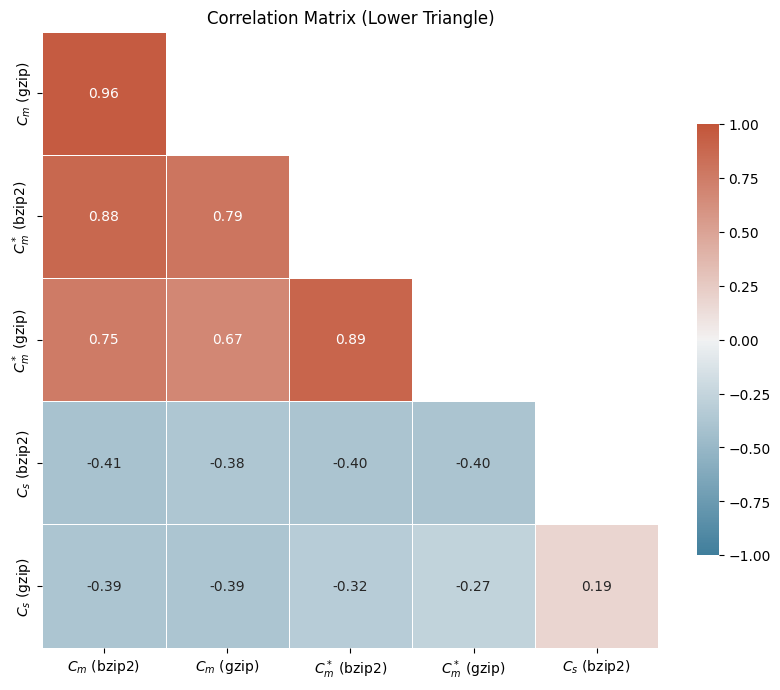

,morphology_deletion_bzip2,morphology_deletion_gzip,morphology_replacement_bzip2,morphology_replacement_gzip,syntactic_deletion_bzip2,syntactic_deletion_gzip
morphology_deletion_bzip2,1.000000,0.958537,0.879059,0.751056,-0.406586,-0.386092
morphology_deletion_gzip,0.958537,1.000000,0.790085,0.672634,-0.378422,-0.386122
morphology_replacement_bzip2,0.879059,0.790085,1.000000,0.893288,-0.397797,-0.323424
morphology_replacement_gzip,0.751056,0.672634,0.893288,1.000000,-0.396972,-0.267966
syntactic_deletion_bzip2,-0.406586,-0.378422,-0.397797,-0.396972,1.000000,0.185988
syntactic_deletion_gzip,-0.386092,-0.386122,-0.323424,-0.267966,0.185988,1.000000


In [28]:
analyze_correlation_matrix(df=variance_experiments_df, metrics_list=SELECTED_METRICS, 
                           metric_labels=METRIC_LABELS)

To remove redundancies and obtain a cohesive set for performing MANOVA and LDA, we decided to remove metrics "morphology_deletion_gzip", "morphology_replacement_bzip2", and "morphology_replacement_gzip". We prioritized removing replacement-based metrics as they proved to be especially non-homogeneous in terms of variance, one of the MANOVA assumptions that will be verified next.

In [29]:
SELECTED_METRICS_FILTERED = [
    "morphology_deletion_bzip2", 
    # "morphology_deletion_gzip", 
    # "morphology_replacement_bzip2", 
    # "morphology_replacement_gzip", 
    "syntactic_deletion_bzip2", 
    "syntactic_deletion_gzip"]

# Verifying MANOVA's Assumptions
- Multivariate Normality
- Correlation Matrix Homogeneity

## Multivariate Normality

In [30]:
def plot_multivariate_qq_by_group(df, metrics_list, target_col='register'):
    """
    Generates multiple Multivariate QQ-Plots (one INDIVIDUAL plot for each group).
    Checks for Multivariate Normality by calculating the Mahalanobis distance
    within each group.
    """
    
    # Validations
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found.")
    
    valid_metrics = [m for m in metrics_list if m in df.columns]
    
    # Clean NaNs
    subset_df = df[[target_col] + valid_metrics].dropna()
    
    # Identify unique groups
    groups = subset_df[target_col].unique()
    n_groups = len(groups)
    
    print(f"--- Verifying Multivariate Normality for {n_groups} groups (Individual Plots) ---")

    # Loop by Group 
    for group_name in groups:
        # Create a new figure for EACH group
        fig, ax = plt.subplots(figsize=(6, 6))
        
        # Filter data ONLY for this group
        group_data = subset_df[subset_df[target_col] == group_name][valid_metrics].values
        n_samples, n_features = group_data.shape
        
        # Sample Size Validation
        # We need more rows than columns to invert the covariance matrix
        if n_samples <= n_features + 1:
            ax.text(0.5, 0.5, f"Insufficient sample\n(N={n_samples})", 
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"Group: {group_name}")
            plt.show() # Render warning and move to next
            continue

        # --- Mahalanobis Distance Calculation  ---
        try:
            # Center the data for this group
            centered_data = group_data - np.mean(group_data, axis=0)
            
            # Covariance Matrix and Inverse
            cov_matrix = np.cov(centered_data, rowvar=False)
            inv_cov_matrix = np.linalg.inv(cov_matrix)
            
            # Mahalanobis Distance (Vectorized)
            left_term = np.dot(centered_data, inv_cov_matrix)
            mahal_sq = np.sum(left_term * centered_data, axis=1)
            
        except np.linalg.LinAlgError:
            ax.text(0.5, 0.5, "Singular Matrix\n(Multicollinearity)", 
                    ha='center', va='center', transform=ax.transAxes, color='red')
            ax.set_title(f"Group: {group_name}")
            plt.show()
            continue

        # --- Theoretical Quantiles (Chi-Square) ---
        sorted_d2 = np.sort(mahal_sq)
        probabilities = (np.arange(1, n_samples + 1) - 0.5) / n_samples
        
        # Degrees of freedom = number of variables (features)
        chi2_quantiles = stats.chi2.ppf(probabilities, df=n_features)

        # --- Plotting ---
        ax.scatter(chi2_quantiles, sorted_d2, alpha=0.6, s=20)
        
        # Reference Line (Identity)
        max_val = max(np.max(chi2_quantiles), np.max(sorted_d2))
        ax.plot([0, max_val], [0, max_val], color='red', linestyle='--', lw=1.5, label='Theoretical Ref.')

        ax.set_title(f"Group: {group_name} (N={n_samples})", fontsize=12, fontweight='bold')
        ax.set_xlabel("Theoretical Quantiles ($\chi^2$)", fontsize=10)
        ax.set_ylabel("Mahalanobis $D^2$", fontsize=10)
        ax.legend()
        ax.grid(True, linestyle=':', alpha=0.4)
        
        # Render and close the current figure to free memory
        plt.tight_layout()
        plt.show()

## Correlation Matrix Homogeinity

--- Verifying Multivariate Normality for 14 groups (Individual Plots) ---


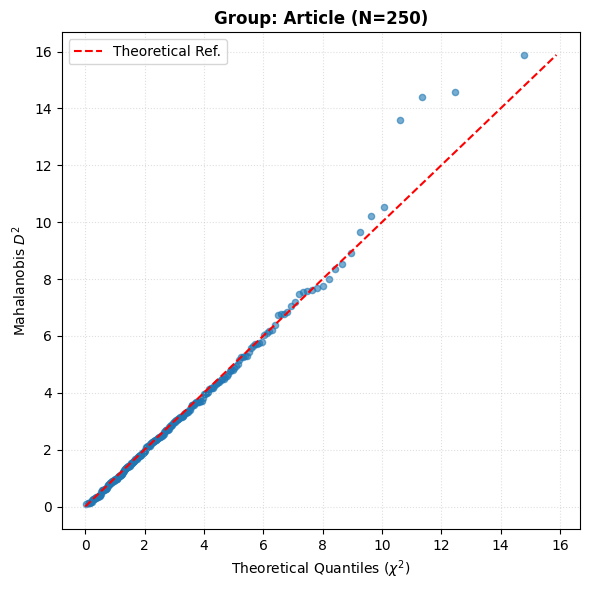

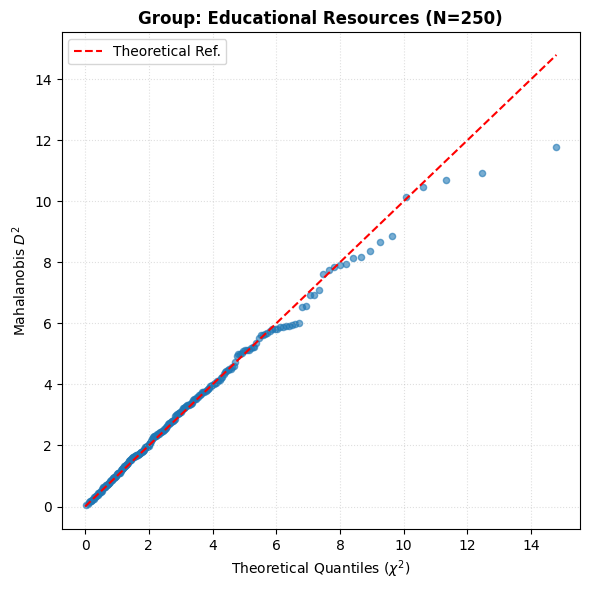

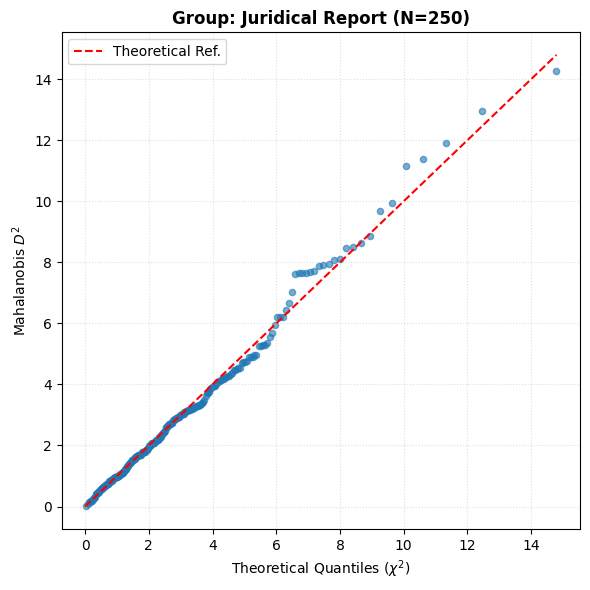

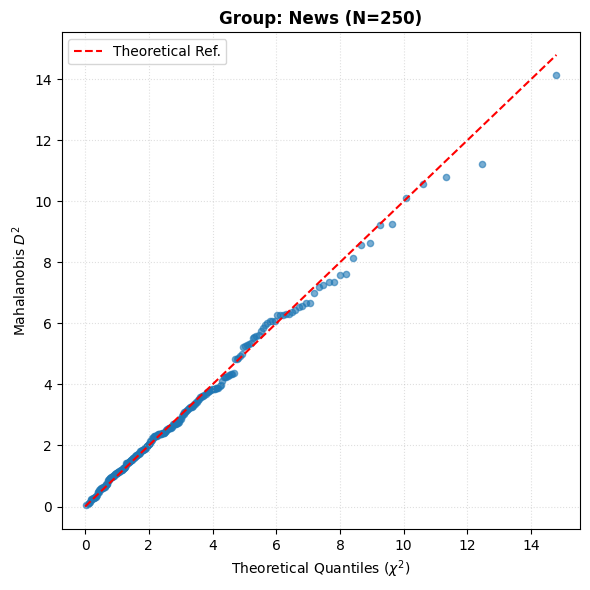

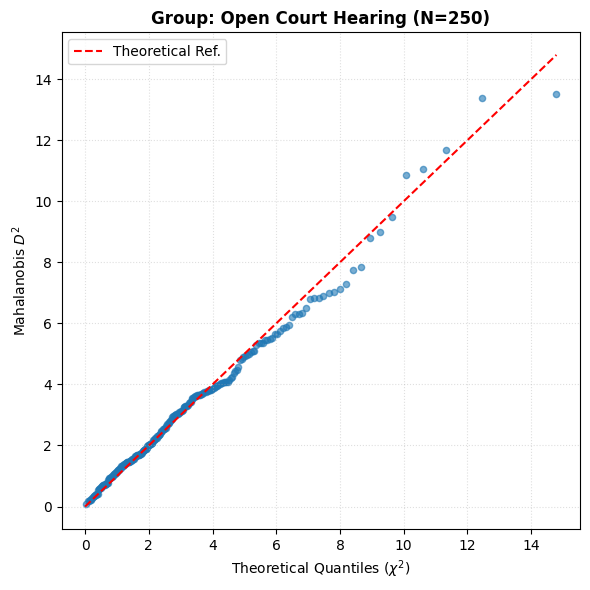

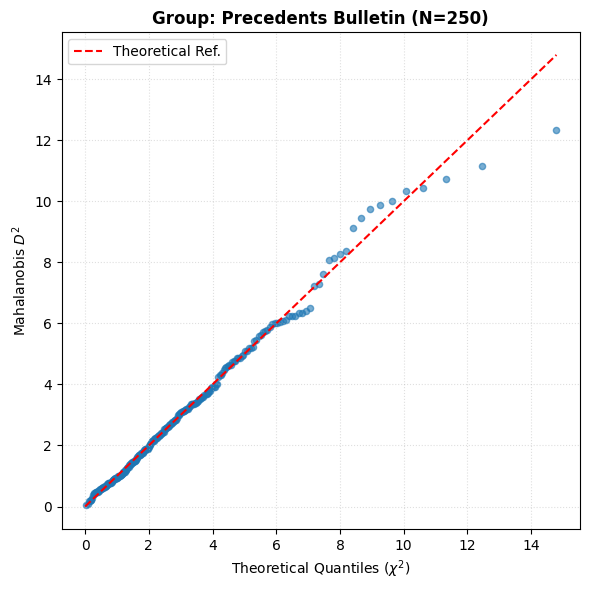

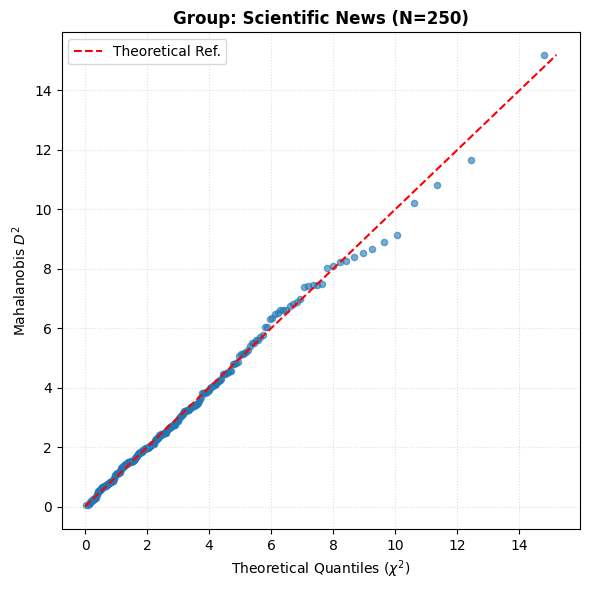

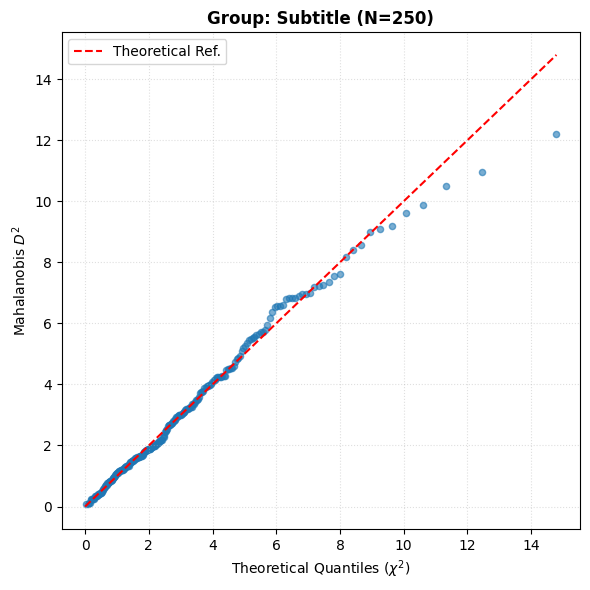

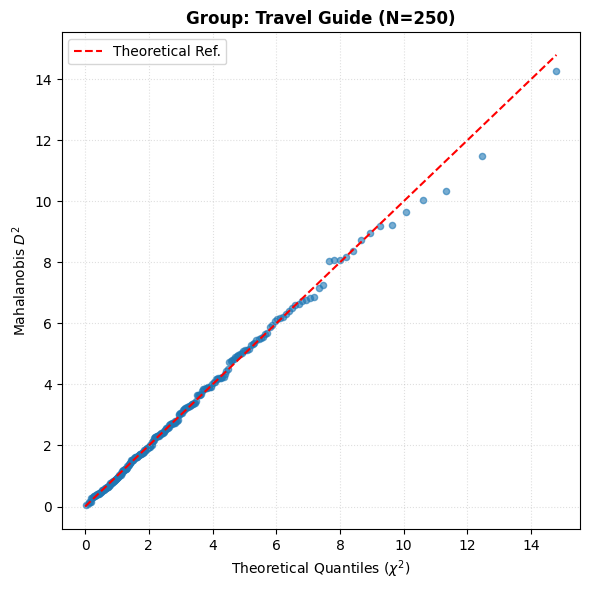

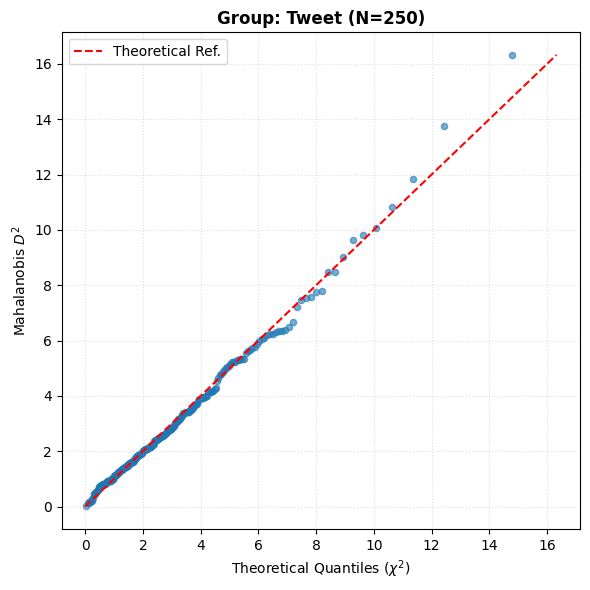

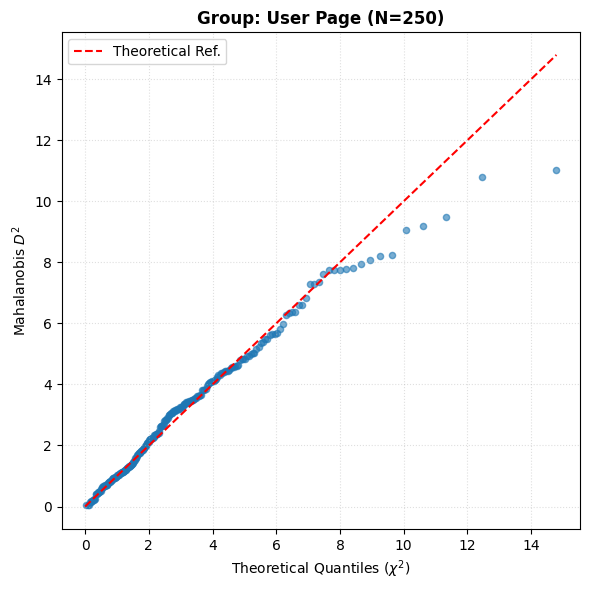

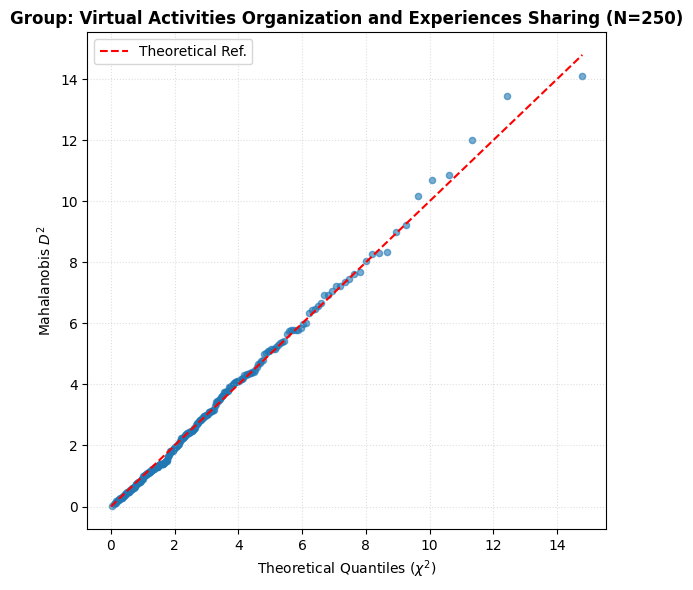

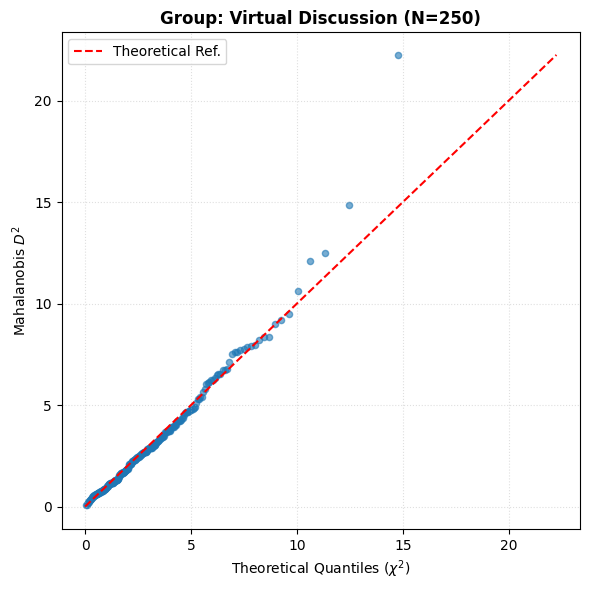

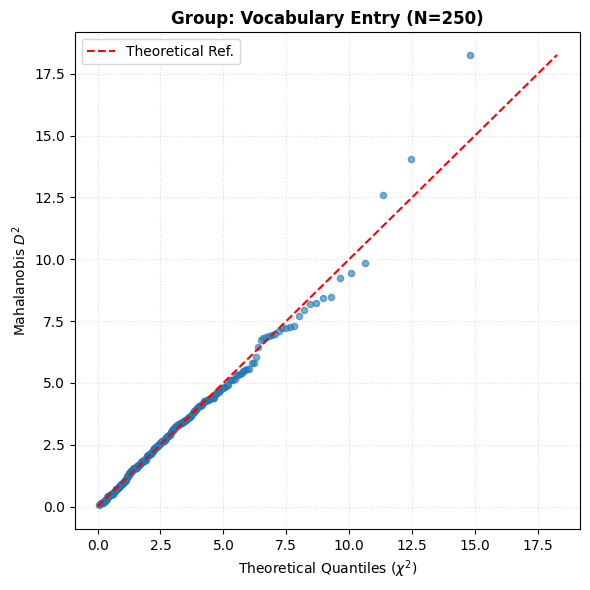

In [31]:
plot_multivariate_qq_by_group(df=variance_experiments_df, metrics_list=SELECTED_METRICS_FILTERED)

## Correlation Matrix Homogeinity

In [ ]:

def check_homogeneity_logdets(df, metrics_list, target_col='register'):
    """
    Checks Homogeneity using Log-Determinants (Generalized Variance).

    
    Args:
        df (pd.DataFrame): Dataframe containing the data.
        metrics_list (list): List of numerical columns.
        target_col (str): Categorical column (groups).
    """
    
    # Validations
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found.")
    
    valid_metrics = [m for m in metrics_list if m in df.columns]
    
    # Create subset and drop missing values
    subset_df = df[[target_col] + valid_metrics].dropna()
    groups = subset_df[target_col].unique()
    n_groups = len(groups)
    n_features = len(valid_metrics)
    
    print(f"--- Homogeneity Analysis (Log-Determinants Only) ---")
    print(f"Groups: {n_groups} | Features: {n_features}")
    print("Criterion: Comparison of Generalized Variance (Log-Determinants).\n")


    # Calculate Log-Determinants per Group
    
    log_dets = {} 
    
    print("--- Group Log-Determinants ---")

    for g in groups:
        g_data = subset_df[subset_df[target_col] == g][valid_metrics].values
        n = len(g_data)
        
        if n <= n_features:
            print(f"CRITICAL ERROR: Group '{g}' has N={n}, insufficient for {n_features} metrics.")
            return

        # Covariance
        cov = np.cov(g_data, rowvar=False)
        
        # Log-Determinant (Generalized Variance in Log scale)
        sign, logdet = np.linalg.slogdet(cov)
        log_dets[g] = logdet
        
        # Display Log-Det
        if sign != 1:
            print(f"Group: {g:<15} | N={n} | WARNING: Negative/Zero Determinant (Log-Det: {logdet:.4f})")
        else:
            print(f"Group: {g:<15} | N={n} | Log-Determinant: {logdet:.4f}")


    # Max Difference 
    
    if not log_dets:
        print("No valid groups found.")
        return

    max_logdet = max(log_dets.values())
    min_logdet = min(log_dets.values())
    diff_logdet = abs(max_logdet - min_logdet)
    
    print(f"\n--- Analysis Results ---")
    print(f"Maximum Log-Det: {max_logdet:.4f}")
    print(f"Minimum Log-Det: {min_logdet:.4f}")
    print(f"MAX DIFFERENCE : {diff_logdet:.4f}") 
    


In [54]:
check_homogeneity_logdets(df=variance_experiments_df, metrics_list=SELECTED_METRICS_FILTERED)

--- Homogeneity Analysis (Log-Determinants Only) ---
Groups: 14 | Features: 3
Criterion: Comparison of Generalized Variance (Log-Determinants).

--- Group Log-Determinants ---
Group: Article         | N=250 | Log-Determinant: -33.3748
Group: Educational Resources | N=250 | Log-Determinant: -33.6222
Group: Juridical Report | N=250 | Log-Determinant: -33.3048
Group: News            | N=250 | Log-Determinant: -34.3721
Group: Open Court Hearing | N=250 | Log-Determinant: -32.9206
Group: Precedents Bulletin | N=250 | Log-Determinant: -31.9260
Group: Scientific News | N=250 | Log-Determinant: -34.2082
Group: Subtitle        | N=250 | Log-Determinant: -32.0195
Group: Travel Guide    | N=250 | Log-Determinant: -33.0072
Group: Tweet           | N=250 | Log-Determinant: -32.7300
Group: User Page       | N=250 | Log-Determinant: -33.5830
Group: Virtual Activities Organization and Experiences Sharing | N=250 | Log-Determinant: -32.9133
Group: Virtual Discussion | N=250 | Log-Determinant: -32.6774


We adopted Huberty’s suggestion to use the difference between the log-determinants of the covariance matrices as a practical heuristic for estimating homogeneity. Small differences suggest that homogeneity is acceptable. After removing highly correlated metrics, we observed a maximum difference of 2.4. Although Huberty explicitly states that there is no standard reference value, we consider this result acceptable, as it indicates that the determinants across groups are of similar order of magnitude. Regardless, it is worth noting that because our groups are balanced, MANOVA is robust to violations of this assumption. Furthermore, relying on Pillai's Trace—the most robust test statistic—provides additional confidence in our results

# MANOVA

In [58]:
def analyze_manova_table(df, metrics_list, target_col='register'):
    """
    Performs a MANOVA (Multivariate ANOVA) Test to verify if the vector of metrics
    varies significantly as a function of the target category.
    
    Args:
        df (pd.DataFrame): Dataframe containing the data.
        metrics_list (list): List of numerical columns (dependent variables).
        target_col (str): Categorical column (independent variable/groups).
        
    Returns:
        pd.DataFrame: Table with multivariate statistics (Wilks' Lambda, Pillai's Trace, etc.).
    """
    
    # Initial Validations
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found.")
    
    # Filter only metrics that exist in the DF
    valid_metrics = [m for m in metrics_list if m in df.columns]
    
    if len(valid_metrics) < 2:
        print("Warning: MANOVA requires at least two dependent variables (metrics).")
        return pd.DataFrame()

    print(f"--- Running MANOVA by '{target_col}' with {len(valid_metrics)} metrics ---")

    # Data Preparation
    # MANOVA requires no NaNs in any of the involved columns (list-wise deletion)
    cols_to_use = [target_col] + valid_metrics
    subset_df = df[cols_to_use].dropna()

    if subset_df.empty:
        print("Error: The dataset is empty after removing NaNs.")
        return pd.DataFrame()

    # Formula Construction
    # We use statsmodels formula syntax: "metric1 + metric2 ~ target"
    # The Q("name") function is used to ensure names with spaces or special characters work.
    dependent_vars = ' + '.join([f'Q("{m}")' for m in valid_metrics])
    formula = f'{dependent_vars} ~ Q("{target_col}")'

    # MANOVA Test Execution
    try:
        manova = MANOVA.from_formula(formula, data=subset_df)
        mv_test_results = manova.mv_test()
        
        # The mv_test object returns results for the Intercept and the Target Variable.
        # We need to extract the table corresponding to the target variable.
        
        target_key = f'Q("{target_col}")'
        
        # Check if the key exists in results (safety check)
        if target_key in mv_test_results.results:
            results_table = mv_test_results.results[target_key]['stat']
        else:
            # Fallback: grab the second result (the first is usually the Intercept)
            print("WARNING:FALLBACK")
            keys = list(mv_test_results.results.keys())
            results_table = mv_test_results.results[keys[1]]['stat']
            
    except Exception as e:
        print(f"Error calculating MANOVA: {e}")
        return pd.DataFrame()

    # Result Formatting
    results_df = pd.DataFrame(results_table)
    
    # Add a column indicating if it is significant (usually using Wilks' Lambda or Pillai's Trace)
    # Here, we apply the generic rule of p < 0.05 for easier visual reading
    results_df['Significant'] = results_df['Pr > F'] < 0.05
    
    return results_df

In [59]:
df_results = analyze_manova_table(df=variance_experiments_df, metrics_list=SELECTED_METRICS_FILTERED, target_col='register')

--- Running MANOVA by 'register' with 3 metrics ---


In [60]:
df_results

,Value,Num DF,Den DF,F Value,Pr > F,Significant
Wilks' lambda,0.034749,39,10317.616155,558.135086,0.0,True
Pillai's trace,1.145058,39.0,10458.0,165.531761,0.0,True
Hotelling-Lawley trace,22.797241,39,8393.540643,2035.869577,0.0,True
Roy's greatest root,22.585717,13,3486,6056.446836,0.0,True


In [67]:
def analyze_lda_loadings(df, metrics_list, target_col='register'):
    """
    Performs LDA to identify which metrics contribute most to the separation of groups.
    Returns the 'Loadings' (weights) of each metric in each Linear Discriminant (LD).
    
    Args:
        df (pd.DataFrame): Dataframe containing the data.
        metrics_list (list): List of numeric columns.
        target_col (str): Categorical column (groups).
        
    Returns:
        pd.DataFrame: Table of Loadings 
    """
    
    # Data Preparation
    valid_metrics = [m for m in metrics_list if m in df.columns]
    if target_col not in df.columns:
        raise ValueError(f"Target '{target_col}' not found.")
        
    # Remove NaNs 
    subset = df[valid_metrics + [target_col]].dropna()
    
    X = subset[valid_metrics]
    y = subset[target_col]
    
    # Number of possible components = min(n_classes - 1, n_features)
    n_classes = y.nunique()
    n_components = min(n_classes - 1, len(valid_metrics))
    
    if n_components == 0:
        print("Error: Not enough classes or metrics to generate components.")
        return pd.DataFrame()

    print(f"--- Running LDA (Target: {target_col}, Classes: {n_classes}, Max Components: {n_components}) ---")

    # Standardization 
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # LDA Model Fitting
    lda = LinearDiscriminantAnalysis(n_components=n_components)
    lda.fit(X_scaled, y)

    # Result Extraction
    loadings = lda.scalings_[:, :n_components]
    
    # Creates the results DataFrame
    columns = [f'LD{i+1}' for i in range(n_components)]
    results_df = pd.DataFrame(loadings, index=valid_metrics, columns=columns)
    
    # Adds a print line with the explained variance 
    explained_variance = lda.explained_variance_ratio_
    print("Explained Variance per Component:")
    for i, var in enumerate(explained_variance):
        print(f"   - LD{i+1}: {var:.1%}")

    # Sorts by the absolute weight in the first component (LD1 - the most important)
    results_df['Abs_LD1'] = results_df['LD1'].abs()
    results_df = results_df.sort_values('Abs_LD1', ascending=False).drop(columns=['Abs_LD1'])

    return results_df

In [68]:
analyze_lda_loadings(df=variance_experiments_df, metrics_list=SELECTED_METRICS_FILTERED, target_col='register')

--- Running LDA (Target: register, Classes: 14, Max Components: 3) ---
Explained Variance per Component:
   - LD1: 99.1%
   - LD2: 0.7%
   - LD3: 0.2%


,LD1,LD2,LD3
morphology_deletion_bzip2,4.908338,0.617190,0.069670
syntactic_deletion_bzip2,0.127749,0.917757,-0.700953
syntactic_deletion_gzip,0.028768,0.695279,0.891778
